In [1]:
%matplotlib inline
import mcstasscript as ms


def make_trex(L0=2.4, RRM=18, mode="HF", freq=14.0):
    trex = ms.McStas_instr(
        "TRex_choppers", author="Bing Li", output_path="trex_choppers"
    )
    trex.settings(suppress_output=True)

    # ------------------- instrument parameters -------------------
    trex.add_parameter(
        "L0",
        value=L0,
        comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
        + "for the source component by adding and subtracting a set wavelength",
    )

    trex.add_parameter(
        "int",
        "RRM",
        value=RRM,
        comment="repetition rate multiplication",
    )

    trex.add_parameter(
        "string",
        "mode",
        value=f'"{mode}"',
        comment="HR for High Resolution, HF for High Flux",
    )

    # ------------------- Declare -------------------
    trex.add_declare_var(
        "double",
        "T_offset",
        value=1.7e-3,
        comment="Time offset in [s] to shift to the center of long pulse",
    )
    trex.add_declare_var(
        "double",
        "f",
        value=freq,
        comment="Source frequency in [Hz]",
    )

    # ------------------- More declare -------------------
    trex.append_declare("""

    double tof_BW1, tof_BW2, tof_P1, tof_P2, tof_M1, tof_M2;

    // characteristic wavelength
    double v0;

    // distances
    double L_BW1 = 32;
    double L_BW2 = 40;
    double L_P1 = 107.95;
    double L_P2 = 108.05;
    double L_M1 = 161.995;
    double L_M2 = 162.005;

    """)

    # ------------------- More declare -------------------

    trex.append_declare("""

    // BW1 Chopper
    double f_BW1;
    double delay_BW1; //time delay

    double radius_BW1 = 0.35;
    double slit_edges_BW1[2] = {-30.7, 30.7};
    double n_edges_BW1 = 2;
    double slit_width_BW1 = 0.06;
    double slit_height_BW1 = 0.095;

    // BW2 Chopper
    double f_BW2;
    double delay_BW2; //time delay

    double radius_BW2 = 0.35;
    double delta_y_BW2 = -0.3075;

    double slit_edges_BW2[2] = {-31.65, 31.65};
    double n_edges_BW2 = 2;
    double slit_width_BW2 = 0.06;
    double slit_height_BW2 = 0.095;


    // P1 Chopper
    double f_P1;
    double delay_P1; //time delay
    double phase_P1;// angular delay

    double radius_P1 = 0.35;
    double delta_y_P1 = 0.305;

    double slit_edges_P1[8] = {-10, 10, 107.5, 142.5, 170, 190, 287.5, 322.5};
    double n_edges_P1 = 8;
    double slit_width_P1 = 0.06;
    double slit_height_P1 = 0.095;



    // P2 Chopper
    double f_P2;
    double delay_P2; //time delay
    double phase_P2;// angular delay

    double radius_P2 = 0.35;
    double delta_y_P2 = 0.305;

    double slit_edges_P2[8] = {-10, 10, 107.5, 142.5, 170, 190, 287.5, 322.5};
    double n_edges_P2 = 8;
    double slit_width_P2 = 0.06;
    double slit_height_P2 = 0.095;



    // M1 Chopper
    double f_M1;
    double delay_M1; //time delay
    double phase_M1;// angular delay

    double radius_M1 = 0.35;
    double delta_y_M1 = 0.325;

    double slit_edges_M1[4] = {178.25, 181.25, 362.8, 367.2};
    double n_edges_M1 = 4;
    double slit_width_M1 = 0.06;
    double slit_height_M1 = 0.045;


    // M2 Chopper
    double f_M2;
    double delay_M2; //time delay
    double phase_M2;// angular delay

    double radius_M2 = 0.35;
    double delta_y_M2 = -0.325;

    double slit_edges_M2[4] = {-1.25, 1.25, 182.8, 187.2};
    double n_edges_M2 = 4;
    double slit_width_M2 = 0.06;
    double slit_height_M2 = 0.045;

    """)
    # ------------------- Initialize -------------------
    trex.append_initialize("""
    // frequencies

    f_BW1 = f;
    f_BW2 = f_BW1;
    f_P1 = RRM*f*0.75;
    f_P2 = -f_P1;
    f_M1 = RRM*f;
    f_M2 = -f_M1;


    // Resolution Settings
    if (strcmp(mode, "HF") == 0){

        for (int i = 0; i < 8; i++) {
            slit_edges_P1[i] += 55;
            slit_edges_P2[i] += 55;
        }
        for (int i = 0; i < 4; i++) {
            slit_edges_M1[i] += 175;
            slit_edges_M2[i] += 175;
        }
    } else {
        printf("Need valid resolution option, 'HR' or 'HF'");
    }


    // characteristic wavelength 

    v0 = 2*PI*K2V/L0; // speed center neutron


    // time of flight and chopper phases
    tof_BW1 = T_offset + L_BW1/v0;
    tof_BW2 = T_offset + L_BW2/v0;
    tof_P1 = T_offset + L_P1/v0;
    tof_P2 = T_offset + L_P2/v0;
    tof_M1 = T_offset + L_M1/v0;
    tof_M2 = T_offset + L_M2/v0;

    //time delay
    delay_BW1 = tof_BW1; 
    delay_BW2 = tof_BW2; 
    delay_P1 = tof_P1; 
    delay_P2 = tof_P2;
    delay_M1 = tof_M1;
    delay_M2 = tof_M2;

   

    """)

    return trex

In [2]:
make_trex().parameters

 - Parameters object -
L0                                  2.4                             wavelength in [Å] used to calculate the minimum and maximum wavelength for the source component by adding and subtracting a set wavelength   
RRM                                 18                              repetition rate multiplication   
mode                                "HF"                            HR for High Resolution, HF for High Flux   

In [3]:
import os
import shutil
import glob


def illuminate_chopper(instrument, chopper):

    pos = chopper.AT_data
    radius = chopper.radius

    if isinstance(radius := chopper.radius, str):
        xwidth = radius + "* 2.5"
        yheight = radius + "* 2.5"
    elif isinstance(radius, (int, float)):
        xwidth = radius * 2.5
        yheight = radius * 2.5
    else:
        raise ValueError(f"Type of chopper radius {radius} not recogonized.")

    # Use Source_div, all neutrons are created at t=0
    source = instrument.add_component(
        "Source",
        "Source_div",
        AT=[pos[0], pos[1], pos[2] - 0.01],
    )
    source.set_parameters(
        xwidth=xwidth * 2,
        yheight=yheight * 2,
        focus_ah=0.001,
        focus_aw=0.001,
        E0=5,
        dE=0.1,
    )
    instrument.move_component(source, before=chopper)

    PSD = instrument.add_component(
        "PSD", "PSD_monitor", AT=[0, 0, 0.5], RELATIVE=source
    )
    PSD.set_parameters(xwidth=source.xwidth, yheight=source.yheight, nx=300, ny=300)

    try:
        instrument.check_for_errors()
    except Exception as e:
        print(str(e))

    data = instrument.backengine()

    base_path = os.path.join(os.getcwd(), trex.output_path)
    for path in glob.glob(base_path) + glob.glob(base_path + "_[0-9]*"):
        if os.path.isdir(path):
            shutil.rmtree(path)

    return data

In [4]:
trex = make_trex()

BW_Chopper_1 = trex.add_component(
    "BW_Chopper_1",
    "NXdisk_chopper",
    AT=[0.011348994153930106, 0.0, 32.0],
    ROTATED=[0, 0.124542024141650, 0],
    comment="Bandwidth chopper 1",
)

BW_Chopper_1.set_parameters(
    slit_edges="slit_edges_BW1",
    n_edges="n_edges_BW1",
    radius=0.35,
    yheight=0.08,
    xwidth=0.0,  # 0.06
    nu="f_BW1",
    delay="delay_BW1",
    beam_angle=0,
    zero_angle=0,
    abs_out=0,
    verbose=1,
)

data_BW1 = illuminate_chopper(trex, BW_Chopper_1)

In [5]:
# trex.show_instrument(backend="pythreejs")

In [6]:
trex = make_trex()

BW_Chopper_2 = trex.add_component(
    "BW_Chopper_2",
    "NXdisk_chopper",
    AT=[0.03140505829452013, 0.0, 40.0],
    ROTATED=[0, 0.162739331227240, 0],
    comment="Bandwidth chopper 2",
)


BW_Chopper_2.set_parameters(
    slit_edges="slit_edges_BW2",
    n_edges="n_edges_BW2",
    radius=0.35,
    yheight=0.08,
    xwidth=0.0,  # 0.06
    nu="f_BW2",
    delay="delay_BW2",
    beam_angle=0,
    zero_angle=0,
    abs_out=0,
    verbose=1,
)

data_BW2 = illuminate_chopper(trex, BW_Chopper_2)

In [7]:
# trex.show_instrument(backend="pythreejs")

In [ ]:
trex = make_trex()

PulseShapingChopper1 = trex.add_component(
    "PulseShapingChopper1",
    "NXdisk_chopper",
    AT=[0.4108460115539497, 0.0, 107.95],
    ROTATED=[0, 0.430122381481144, 0],
    comment="/* ---------------------- P-Choppers -------------------- */",
)

PulseShapingChopper1.set_parameters(
    slit_edges="slit_edges_P1",
    n_edges="n_edges_P1",
    radius=0.35,
    yheight=0.08,
    xwidth=0.0,  # 0.06
    nu="f_P1",
    delay="delay_P1",
    beam_angle=180,
    zero_angle=0,
    abs_out=0,
    verbose=1,
)

data_P1 = illuminate_chopper(trex, PulseShapingChopper1)

In [9]:
# trex.show_instrument(backend="pythreejs")

In [ ]:
trex = make_trex()

PulseShapingChopper2 = trex.add_component(
    "PulseShapingChopper2",
    "NXdisk_chopper",
    AT=[0.41159673083080733, 0.0, 108.05],
    ROTATED=[0, 0.430122381481144, 0],
)


PulseShapingChopper2.set_parameters(
    slit_edges="slit_edges_P2",
    n_edges="n_edges_P2",
    radius=0.35,
    yheight=0.08,
    xwidth=0.0,  # 0.06
    nu="f_P2",
    delay="delay_P2",
    beam_angle=180,
    zero_angle=0,
    abs_out=0,
    verbose=1,
)


data_P2 = illuminate_chopper(trex, PulseShapingChopper2)

In [11]:
# trex.show_instrument(backend="pythreejs")

In [12]:
trex = make_trex()

MonochromatingChopper1 = trex.add_component(
    "MonochromatingChopper1",
    "NXdisk_chopper",
    AT=[0.8166097806955753, 0.0, 161.995],
    ROTATED=[0, 0.430122381481144, 0],
    comment="/* ---------------------- M-Choppers -------------------- */",
)

MonochromatingChopper1.set_parameters(
    slit_edges="slit_edges_M1",
    n_edges="n_edges_M1",
    radius=0.35,
    yheight=0.08,
    xwidth=0.0,  # 0.06
    nu="f_M1",
    delay="delay_M1",
    beam_angle=180,
    zero_angle=0,
    abs_out=0,
    verbose=1,
)

data_M1 = illuminate_chopper(trex, MonochromatingChopper1)

In [13]:
# trex.show_instrument(backend="pythreejs")

In [14]:
trex = make_trex()

MonochromatingChopper2 = trex.add_component(
    "MonochromatingChopper2",
    "NXdisk_chopper",
    AT=[0.8166097806955753, 0.0, 162.005],
    ROTATED=[0, 0.430122381481144, 0],
)


MonochromatingChopper2.set_parameters(
    slit_edges="slit_edges_M2",
    n_edges="n_edges_M2",
    radius=0.35,
    yheight=0.08,
    xwidth=0.0,  # 0.06
    nu="f_M2",
    delay="delay_M2",
    beam_angle=0,
    zero_angle=0,
    abs_out=0,
    verbose=1,
)

data_M2 = illuminate_chopper(trex, MonochromatingChopper2)

In [15]:
# trex.show_instrument(backend="pythreejs")

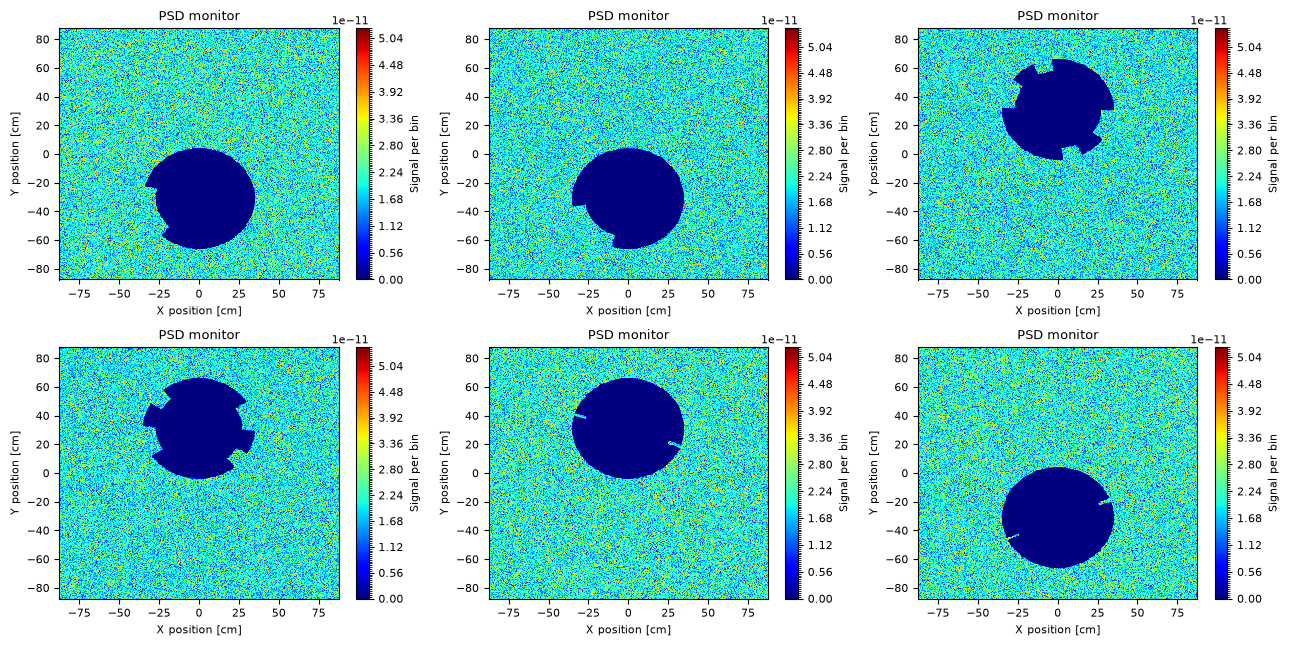

In [16]:
ms.make_sub_plot(
    data_BW1 + data_BW2 + data_P1 + data_P2 + data_M1 + data_M2,
    fontsize=8,
    aspects="equal",
)